# Cats and Dogs Assignment and Walkthrough

In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

## This tutorial was adapted from Cholett (2021)
## You will build a CNN using transfer learning and data augmentation. The data images have already been split into training, validation, and test sets.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os, shutil # Library for navigating files
from keras import backend as K
from keras import backend, models, layers, optimizers, regularizers
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from IPython.display import display # Library to help view images
from PIL import Image # Library to help view images
# from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Library for data augmentation
from keras.preprocessing import image

np.random.seed(1)

### We need to mount the google drive to access the images. Paste the authorization code into your browser

In [9]:
from google.colab import drive  # Library to mount google drives
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [19]:
# Specify the base directory where images are located.  You need to access your data here.
base_dir = '/content/drive/MyDrive/Dogs vs Cats Small/dogs vs cats_small'

In [20]:
# Specify the training, validation, and test directories.
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [21]:
# Specify the classess in the training, validataion, and test directories
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')

validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

test_cats_dir = os.path.join(test_dir, 'cats')
test_dogs_dir = os.path.join(test_dir, 'dogs')

In [13]:
!ls "/content/drive/MyDrive/Dogs vs Cats Small"

'dogs vs cats_small'


In [22]:
# Check the number of files in each class dirrectory
print(len(os.listdir(train_cats_dir)))
print(len(os.listdir(train_dogs_dir)))
print(len(os.listdir(validation_cats_dir)))
print(len(os.listdir(validation_dogs_dir)))
print(len(os.listdir(test_cats_dir)))
print(len(os.listdir(test_dogs_dir)))

1000
1000
500
500
500
500


In [23]:
# We need to normalize the pixels in the images.  The data will 'flow' through this generator.
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [24]:
# Since the file images are in a directory we need to move them from the directory into the model.
# Keras as a function that makes this easy. Documentaion is here: https://keras.io/preprocessing/image/

train_generator = train_datagen.flow_from_directory(
    train_dir, # The directory where the train data is located
    target_size=(150, 150), # Reshape the image to 150 by 150 pixels. This is important because it makes sure all images are the same size.
    batch_size=20, # We will take images in batches of 20.
    class_mode='binary') # The classification is binary.

validation_generator = train_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [25]:
# Build a plotting function
def plot_history(history):
  history_dict = history.history
  loss_values = history_dict['loss']
  val_loss_values = history_dict['val_loss']
  acc_values = history_dict['accuracy']
  val_acc_values = history_dict['val_accuracy']
  epochs = range(1, len(history_dict['accuracy']) + 1)

  plt.plot(epochs, loss_values, 'bo', label = 'Training loss')
  plt.plot(epochs, val_loss_values, 'b', label = 'Validation loss')
  plt.title('Training and validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  plt.plot(epochs, acc_values, 'bo', label = 'Training accuracy')
  plt.plot(epochs, val_acc_values, 'b', label = 'Validation accuracy')
  plt.title('Training and validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  return plt.show()

In [26]:
# Build a model
def Base_CNN():
  backend.clear_session()
  model = models.Sequential()

  model.add(layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (150, 150, 3)))
  model.add(layers.MaxPool2D((2,2)))
  model.add(layers.BatchNormalization())

  model.add(layers.Conv2D(32, (3,3), activation = 'relu'))
  model.add(layers.MaxPool2D((2,2)))
  model.add(layers.BatchNormalization())

  model.add(layers.Conv2D(32, (3,3), activation = 'relu'))
  model.add(layers.MaxPool2D((2,2)))
  model.add(layers.BatchNormalization())

  model.add(layers.Flatten())
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dropout(0.5))

  model.add(layers.Dense(1, activation='sigmoid'))

  model.compile(optimizer = 'rmsprop',
                loss = 'binary_crossentropy',
                metrics = ['accuracy'])
  return model

In [27]:
model = Base_CNN()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 359s 4s/step - accuracy: 0.5731 - loss: 2.0657 - val_accuracy: 0.5000 - val_loss: 0.9988
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.6573 - loss: 1.0650 - val_accuracy: 0.5050 - val_loss: 1.0092
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 146ms/step - accuracy: 0.7408 - loss: 0.6388 - val_accuracy: 0.5040 - val_loss: 0.8513
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.8114 - loss: 0.4377 - val_accuracy: 0.5460 - val_loss: 0.8541
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 142ms/step - accuracy: 0.8201 - loss: 0.4231 - val_accuracy: 0.6210 - val_loss: 0.8051
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.8714 - loss: 0.2941 - val_accuracy: 0.6960 - val_loss: 0.7615
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 141ms/step - accuracy: 0.8857 - loss: 0.2652 - val_accuracy: 0.6280 - val_loss: 3.3396
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 148ms/step - accuracy: 0.9141 - loss: 0.2

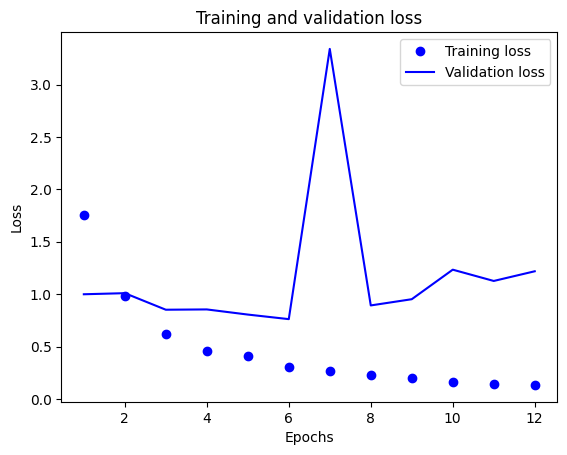

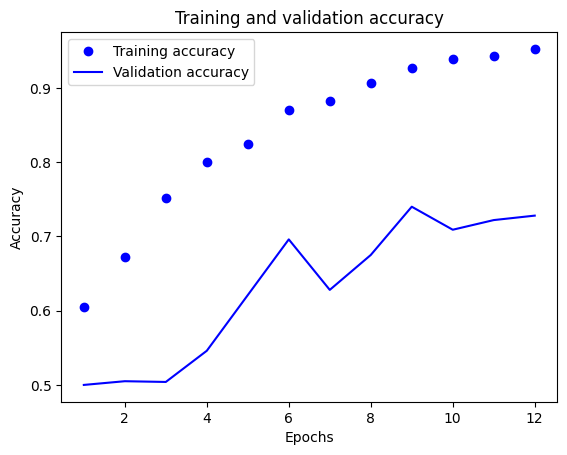

50/50 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.7406 - loss: 0.9810


test_acc: 0.7279999852180481


In [28]:
history = model.fit( # The image data must come from the image generator that takes the images from the correct dirrectory. https://keras.io/models/sequential/
    train_generator, # Images are taken from the train_generator
    steps_per_epoch=100, # The number of steps from the train_generator before one epoch if finished.
                         # 100 steps * 20 batch size in train generator = 2000 training images per epoch. This way each traning image will be sampled once per epoch.
    epochs=50, # Train data for 50 epochs
    validation_data=validation_generator, # Take data from the validataion generator
    validation_steps=50, # 50 steps * 20 batch size in validation generator = 1000 validation images per epoch
    verbose = 1,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights = True)]) # We will not use call backs to stop early.

plot_history(history) # Use our plot function to plot the loss and accuracy.

test_loss, test_acc =model.evaluate(test_generator, steps = 50) # Test images are in a dirrectory so they must flow from dirrectory.
                                                                           # 50 steps * 20 batch size in test generator = 1000 test images per epoch
print('test_acc:', test_acc)

model.save('cats_and_dogs_base.h5')

### The above model came out with about 70% accuracy with severe overfitting, which is pretty good considering we only used 2000 training images!  Now let's improve using data augmentation.

#### Data augmentation allows us to randomly transform images before sending them to the model for training.  The random transformation changes the images into 'new' images and allows for an increase in traning data without have additional images. https://keras.io/preprocessing/image/

---



In [29]:
datagen = ImageDataGenerator( # The image augmentation function in Keras
    rotation_range=40, # Rotate the images randomly by up to 40 degrees
    width_shift_range=0.2, # Shift the image horizontally by up to 20%
    height_shift_range=0.2, # Shift the image vertically by up to 20%
    shear_range=0.2, # Shear image by up to 20%
    zoom_range=0.2, # Zoom in on image by up to 20%
    horizontal_flip=True, # Flip image horizontally
    fill_mode='nearest'
    ) # How to fill missing pixels after a augmentaion opperation

Found 2000 images belonging to 2 classes.


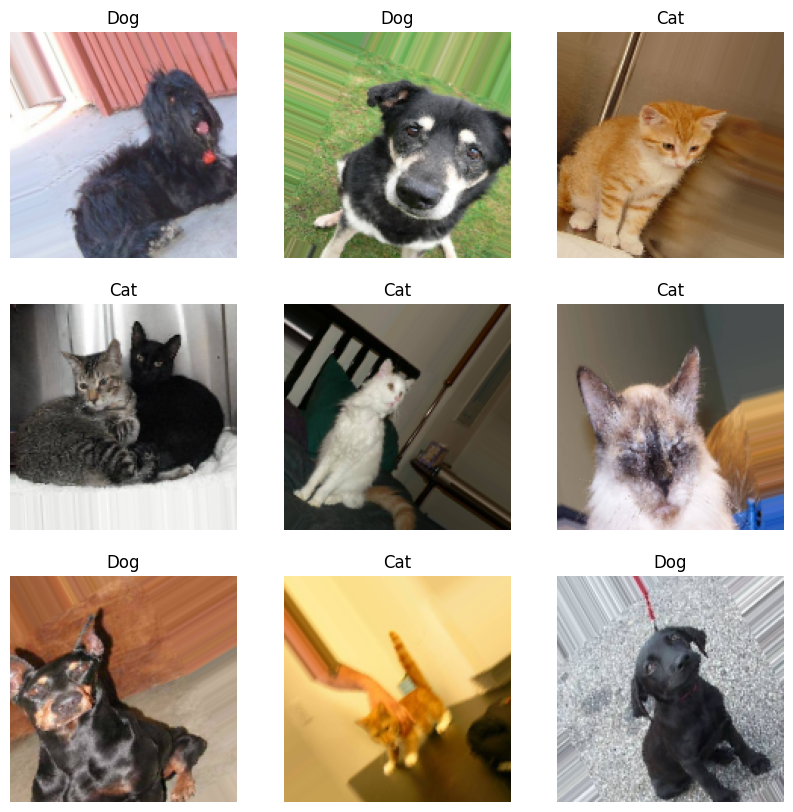

In [30]:
# Let's see the image augmentaion
image_batch, label_batch = next(iter(datagen.flow_from_directory(
  train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')))

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  label = ['Cat', 'Dog'][int(label_batch[i])]
  plt.title(label)
  plt.axis("off")

In [31]:
# Apply the data augmentation to our data.
train_datagen2 = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen2 = ImageDataGenerator(rescale=1./255) #Never apply data augmentation to test data.  You only want to normalize and resize test data.

train_generator2 = train_datagen2.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator2 = train_datagen2.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

test_generator2 = test_datagen2.flow_from_directory( # Resize test data
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 318ms/step - accuracy: 0.6054 - loss: 1.1200 - val_accuracy: 0.5810 - val_loss: 0.8188
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 334ms/step - accuracy: 0.6160 - loss: 0.7163 - val_accuracy: 0.5930 - val_loss: 0.7000
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.6524 - loss: 0.6803 - val_accuracy: 0.5930 - val_loss: 0.6501
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.6379 - loss: 0.6767 - val_accuracy: 0.6040 - val_loss: 0.8104
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 324ms/step - accuracy: 0.6840 - loss: 0.6144 - val_accuracy: 0.6530 - val_loss: 0.6277
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.6668 - loss: 0.6098 - val_accuracy: 0.7110 - val_loss: 0.5769
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step - accuracy: 0.6653 - loss: 0.6334 - val_accuracy: 0.6660 - val_loss: 0.6318
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 314ms/step - accuracy: 0.6641 - loss: 0

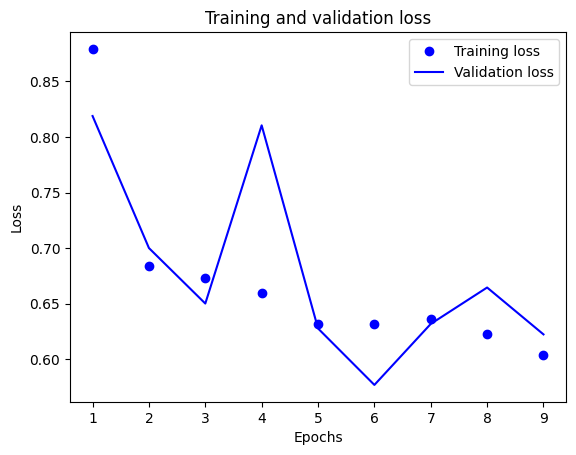

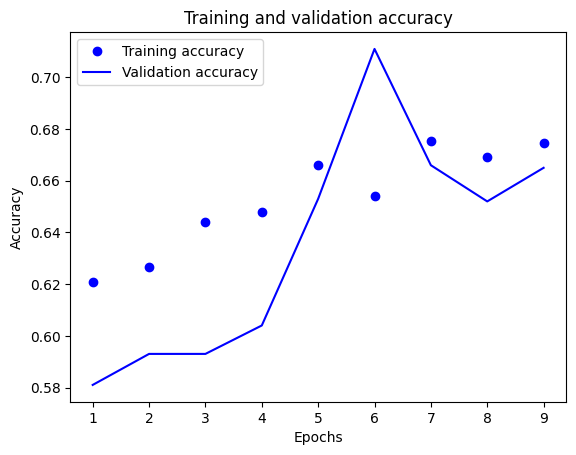

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.6929 - loss: 0.6283


test_acc: 0.6949999928474426


In [32]:
history = model.fit(
    train_generator2,
    steps_per_epoch=100,
    epochs=50,
    validation_data=validation_generator2,
    validation_steps=50,
    verbose = 1,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights = True)])


plot_history(history)

test_loss, test_acc = model.evaluate(test_generator2, steps = 50)
print('test_acc:', test_acc)

model.save('cats_and_dogs_base_augment.h5')

## An inprovement, but not a surprise. Having more data helps our accuracy.
### But why go through the hassle of building our own CNN when there are many networks that have used powerful GPUs to classify images? We can use the weights of their models and apply them to something as simple as classiying a dog and cat.  We will use weights of the VGG16 CNN that was trained using ImageNet data.  https://keras.io/applications/

In [33]:
from keras.applications import VGG16 # Import the VGG16 library.

In [34]:
backend.clear_session()
conv_base = VGG16 (weights = 'imagenet', #Using the VGG66 CNN that was trained on ImageNet data.
                  include_top = False, # We are using our own classification (dog or cat) and not the ImageNet multiclassification. So include top = false.
                  input_shape = (150, 150, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
conv_base.summary() # View the VGG16 model architecture.

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### The output shape of the data after the VGG16 weights are applied is (4, 4, 512).  Remember it started as (150, 150, 3).  This is from the 2D convolutions and maxpooling steps.  There are also over 14 million parameters to train.  This is way too many for the Google GPU. And we do not want to retrain the weights of the VGG16, that defeats the whole purpose of transfer learning.  Instead we will freeze the VGG16 weights and add a dense layer at the end.  

In [36]:
conv_base.trainable = False # Freeze the VGG16 weights.

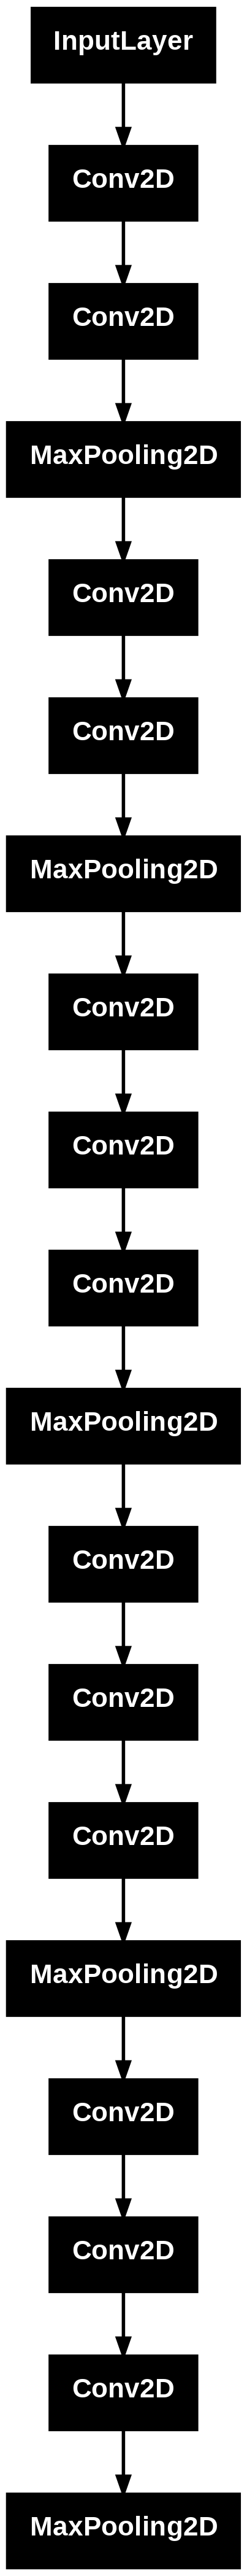

In [38]:
from tensorflow.keras.utils import plot_model

plot_model(conv_base)

In [39]:
conv_base.summary()# Lets look at the parameters now.

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

### Now the trainable parameters are 0.  We will only use the pretrained VGG16 weights.

In [40]:
def modelvgg():
  backend.clear_session()
  modelvgg16 = models.Sequential()
  modelvgg16.add(conv_base) # Add the VG166 weights
  modelvgg16.add(layers.Flatten())
  modelvgg16.add(layers.Dense(512, activation = 'relu'))
  modelvgg16.add(layers.Dense(1, activation = 'sigmoid'))

  modelvgg16.compile(optimizer = 'rmsprop',
                      loss = 'binary_crossentropy',
                      metrics = ['accuracy'])


  return modelvgg16

In [41]:
model = modelvgg()

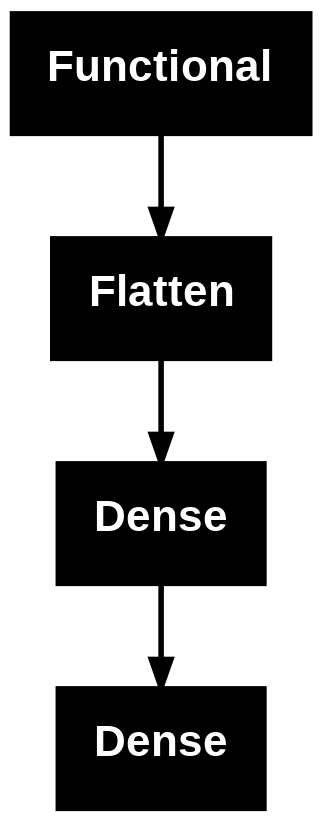

In [42]:
plot_model(model)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 391ms/step - accuracy: 0.6176 - loss: 1.5381 - val_accuracy: 0.8240 - val_loss: 0.4081
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.7704 - loss: 0.4785 - val_accuracy: 0.8260 - val_loss: 0.3813
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 379ms/step - accuracy: 0.7965 - loss: 0.4242 - val_accuracy: 0.7220 - val_loss: 0.6145
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 371ms/step - accuracy: 0.8283 - loss: 0.3884 - val_accuracy: 0.8390 - val_loss: 0.3571
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.8516 - loss: 0.3318 - val_accuracy: 0.8280 - val_loss: 0.3582
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 372ms/step - accuracy: 0.8384 - loss: 0.3493 - val_accuracy: 0.8100 - val_loss: 0.3997
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 385ms/step - accuracy: 0.8202 - loss: 0.3507 - val_accuracy: 0.8470 - val_loss: 0.3449
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 38s 379ms/step - accuracy: 0.8389 - loss: 0

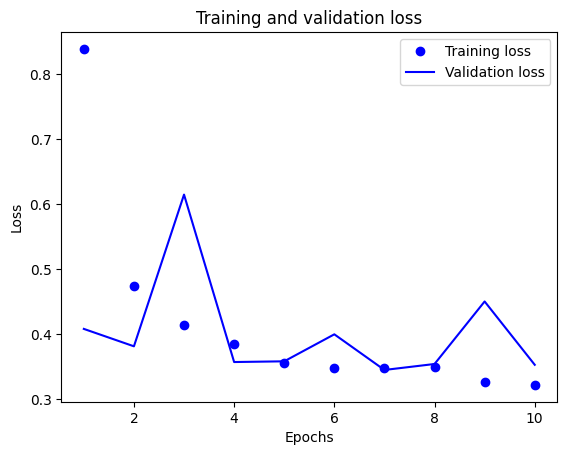

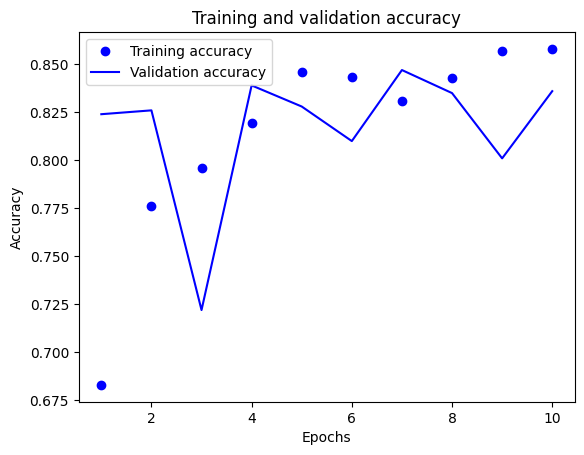

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8835 - loss: 0.2791


test_acc: 0.875


In [43]:
# We will still use data augmentation
history = model.fit(
    train_generator2,
    steps_per_epoch=100,
    epochs=50,
    validation_data=validation_generator2,
    validation_steps=50,
    verbose = 1,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights = True)])

plot_history(history)

test_loss, test_acc = model.evaluate(test_generator2, steps = 50)
print('test_acc:', test_acc)

model.save('cats_and_dogs_vgg.h5')

### Our model keeps getting better. We might want to add a few 2D convolutions and max pooling layers before the dense layer, or we can train the last three 2D convolution layers and MaxPooling layer of the VGG16 model. We must be strategic when choosing which layers to train in the transfer model.  We want to train convolution, max pooling, batch normalization, etc., layers that are part of block.  It would not make sense to only train max pooling or batch normalization layers without also training the convolution layers.

In [44]:
# Now we can freeze all the VGG weights except the last few, and train those before adding it to our dense layer.
backend.clear_session()
vgg16_base_2 = VGG16(weights = 'imagenet', include_top = False, input_shape = (150, 150, 3))

# Here we freeze all the layers except the last 2.
for layer in vgg16_base_2.layers[:-2]:
  layer.trainable = False
for layer in vgg16_base_2.layers:
  print(layer, layer.trainable)

<InputLayer name=input_layer, built=True> False
<Conv2D name=block1_conv1, built=True> False
<Conv2D name=block1_conv2, built=True> False
<MaxPooling2D name=block1_pool, built=True> False
<Conv2D name=block2_conv1, built=True> False
<Conv2D name=block2_conv2, built=True> False
<MaxPooling2D name=block2_pool, built=True> False
<Conv2D name=block3_conv1, built=True> False
<Conv2D name=block3_conv2, built=True> False
<Conv2D name=block3_conv3, built=True> False
<MaxPooling2D name=block3_pool, built=True> False
<Conv2D name=block4_conv1, built=True> False
<Conv2D name=block4_conv2, built=True> False
<Conv2D name=block4_conv3, built=True> False
<MaxPooling2D name=block4_pool, built=True> False
<Conv2D name=block5_conv1, built=True> False
<Conv2D name=block5_conv2, built=True> False
<Conv2D name=block5_conv3, built=True> True
<MaxPooling2D name=block5_pool, built=True> True


In [45]:
vgg16_base_2.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 2,359,808 (9.00 MB)

 Non-trainable params: 12,354,880 (47.13 MB)

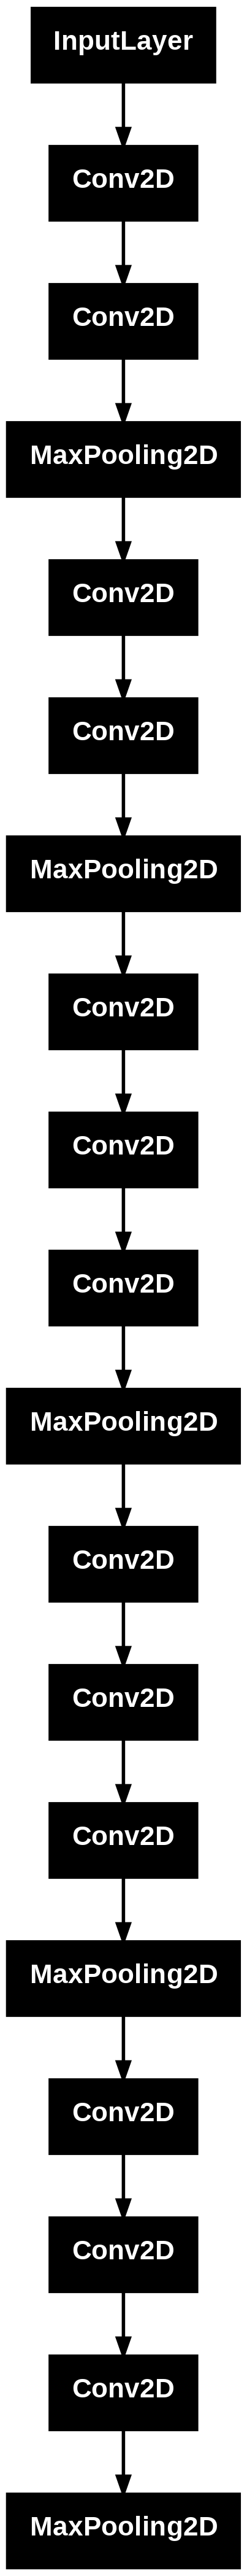

In [46]:
plot_model(vgg16_base_2)

In [47]:
def model_vgg_train():
  backend.clear_session()
  modelvgg16_train = models.Sequential()
  modelvgg16_train.add(vgg16_base_2)
  modelvgg16_train.add(layers.Flatten())
  modelvgg16_train.add(layers.Dense(512, activation = 'relu'))
  modelvgg16_train.add(layers.Dense(1, activation = 'sigmoid'))

  modelvgg16_train.compile('rmsprop',
    loss = 'binary_crossentropy',
    metrics = ['accuracy'])

  return modelvgg16_train

In [48]:
model = model_vgg_train()

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 382ms/step - accuracy: 0.6129 - loss: 2.4242 - val_accuracy: 0.8290 - val_loss: 0.3585
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 357ms/step - accuracy: 0.8256 - loss: 0.4338 - val_accuracy: 0.8510 - val_loss: 0.3490
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 370ms/step - accuracy: 0.8336 - loss: 0.3899 - val_accuracy: 0.7830 - val_loss: 0.5790
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 368ms/step - accuracy: 0.8589 - loss: 0.3258 - val_accuracy: 0.8370 - val_loss: 0.3419
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 357ms/step - accuracy: 0.8772 - loss: 0.3074 - val_accuracy: 0.8670 - val_loss: 0.3283
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 370ms/step - accuracy: 0.8748 - loss: 0.2953 - val_accuracy: 0.8220 - val_loss: 0.3669
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 360ms/step - accuracy: 0.8693 - loss: 0.2962 - val_accuracy: 0.8850 - val_loss: 0.2939
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 363ms/step - accuracy: 0.8885 - loss: 0

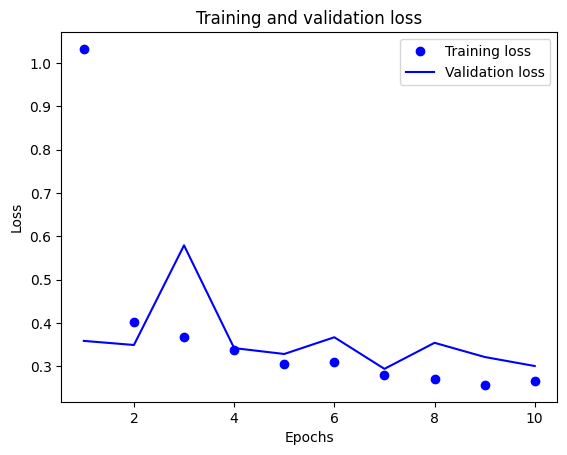

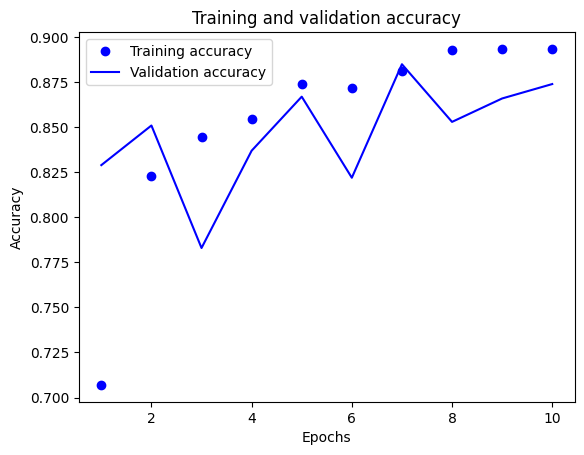

50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.9265 - loss: 0.2231


test_acc: 0.9150000214576721


In [49]:
history = model.fit(
    train_generator2,
    steps_per_epoch=100,
    epochs=50,
    validation_data=validation_generator2,
    validation_steps=50,
    verbose = 1,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights = True)])


plot_history(history)

test_loss, test_acc = model.evaluate(test_generator2, steps = 50)
print('test_acc:', test_acc)

model.save('cats_and_dogs_small_vgg_train.h5')

### The best model yet!

# Your Turn
### Build and optimize another model. Use weights from a different pretrained network (e.g., ResNet, Inception, etc. -- not VGG) from the [Keras library](https://keras.io/applications/). Optimize the model by adding additional layers, regularization, change activation, adjust data augmentation, etc.

# EfficientNetB0

In [50]:
import os
import numpy as np
from keras import backend as K
from keras import models, layers, optimizers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [51]:
# Robust import for EfficientNet + preprocess
try:
    from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
except Exception:
    from keras.applications.efficientnet import EfficientNetB0, preprocess_input

In [52]:
# EfficientNet Transfer Learning: Cats vs Dogs (New Model)
# Image size & training params
IMG_SIZE = 224         # EfficientNet works best at >= 224
BATCH_SIZE = 32
SEED = 1
EPOCHS_HEAD = 30       # train head with base frozen
EPOCHS_FT = 30         # fine-tune some deeper layers
L2 = 1e-4

In [53]:

# Data augmentation (stronger than before) + correct preprocessing
train_datagen3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=35,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
valid_test_datagen3 = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator3 = train_datagen3.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=SEED,
)
validation_generator3 = valid_test_datagen3.flow_from_directory(
    validation_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)
test_generator3 = valid_test_datagen3.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [54]:

# Build EfficientNetB0 model with a regularized classification head
def build_efficientnet_model(img_size=IMG_SIZE, l2=L2):
    K.clear_session()
    base = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(img_size, img_size, 3)
    )
    base.trainable = False  # freeze base for initial training

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)               # keep batch-norms in inference mode
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='swish', kernel_regularizer=regularizers.l2(l2))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # compile with a conservative LR for the new head
    opt = optimizers.Adam(learning_rate=1e-3)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model, base

model_e, base_e = build_efficientnet_model()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:

# Callbacks
ckpt_head = ModelCheckpoint('cats_and_dogs_efficientnet_head.h5', save_best_only=True, monitor='val_accuracy', mode='max')
early = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9141 - loss: 0.2382

62/62 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.9148 - loss: 0.2370 - val_accuracy: 0.9808 - val_loss: 0.0945 - learning_rate: 0.0010
Epoch 2/30
 1/62 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9688 - loss: 0.1457

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - accuracy: 0.9688 - loss: 0.1457 - val_accuracy: 0.9829 - val_loss: 0.0930 - learning_rate: 0.0010
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.9757 - loss: 0.1236

62/62 ━━━━━━━━━━━━━━━━━━━━ 42s 676ms/step - accuracy: 0.9757 - loss: 0.1236 - val_accuracy: 0.9899 - val_loss: 0.0794 - learning_rate: 0.0010
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 1.0000 - loss: 0.0548 - val_accuracy: 0.9899 - val_loss: 0.0791 - learning_rate: 0.0010
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9796 - loss: 0.1155

62/62 ━━━━━━━━━━━━━━━━━━━━ 82s 756ms/step - accuracy: 0.9796 - loss: 0.1155 - val_accuracy: 0.9909 - val_loss: 0.0693 - learning_rate: 0.0010
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9688 - loss: 0.0968 - val_accuracy: 0.9909 - val_loss: 0.0694 - learning_rate: 0.0010
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9785 - loss: 0.1030
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 663ms/step - accuracy: 0.9785 - loss: 0.1030 - val_accuracy: 0.9909 - val_loss: 0.0692 - learning_rate: 0.0010
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9688 - loss: 0.0871 - val_accuracy: 0.9909 - val_loss: 0.0693 - learning_rate: 5.0000e-04
Epoch 9/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.9816 - loss: 0.0879
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 651ms/step - accuracy: 0.9816 - loss: 0.0880 - val_accuracy: 0.9919 - val_loss: 0.0704 - learning_rate: 5.0000e-04
Epoch 10/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 1.0000 - loss: 0.0446 - val_accuracy: 0.9919 - val_loss: 0.0704 - learning_rate: 2.5000e-04
Epoch 11/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.9797 - loss: 0.0952
Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 650ms/step - accuracy: 0.9797 - loss: 0.0953 - val_accuracy: 0.9919 - val_loss: 0.0695 - learning_rate: 2.5000e-04
Epoch 12/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 1.0000 - loss: 0.0459 - val_accuracy: 0.9919 - val_loss: 0.0695 - learning_rate: 1.2500e-04
Epoch 13/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.9826 - loss: 0.0973
Epoch 13: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
62/62 ━━━━━━━━━━━━━━━━━━━━ 40s 647ms/step - accuracy: 0.9826 - loss: 

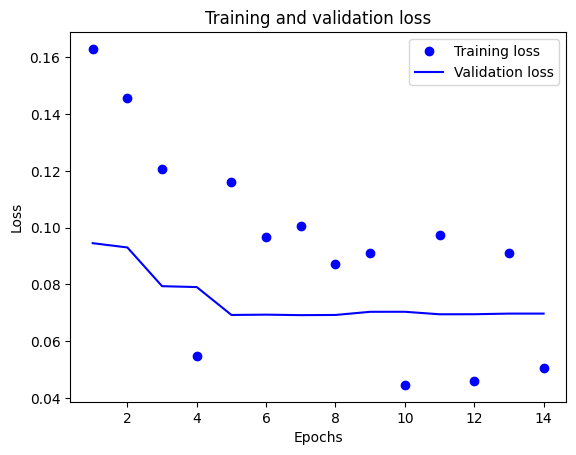

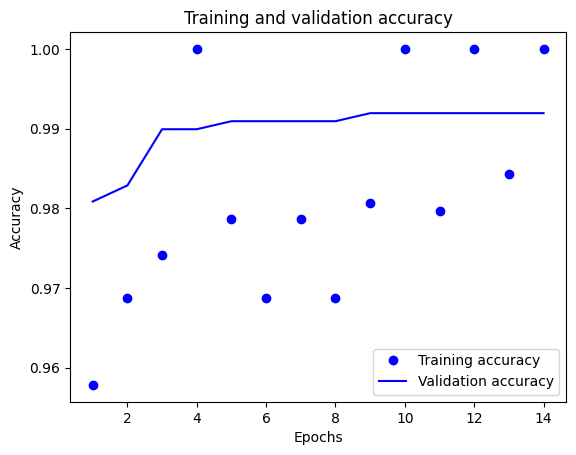

In [56]:
# Train classification head (base frozen)
history_head = model_e.fit(
    train_generator3,
    steps_per_epoch=train_generator3.samples // BATCH_SIZE,
    epochs=EPOCHS_HEAD,
    validation_data=validation_generator3,
    validation_steps=validation_generator3.samples // BATCH_SIZE,
    callbacks=[early, reduce, ckpt_head],
    verbose=1
)

plot_history(history_head)


In [57]:
# Evaluate on test set (base frozen version)
test_loss_head, test_acc_head = model_e.evaluate(test_generator3, steps=test_generator3.samples // BATCH_SIZE, verbose=1)
print(f'[Frozen-Base] Test Accuracy: {test_acc_head:.4f}')


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.9921 - loss: 0.0633
[Frozen-Base] Test Accuracy: 0.9909


In [58]:
# Fine-tune: unfreeze deeper layers (last ~30 layers is a good start)
base_e.trainable = True
FINE_TUNE_AT = len(base_e.layers) - 30  # unfreeze last 30 layers
for i, layer in enumerate(base_e.layers):
    layer.trainable = (i >= FINE_TUNE_AT)

# Use a much lower LR for fine-tuning to avoid catastrophic forgetting
opt_ft = optimizers.Adam(learning_rate=3e-5)
model_e.compile(optimizer=opt_ft, loss='binary_crossentropy', metrics=['accuracy'])

ckpt_ft = ModelCheckpoint('cats_and_dogs_efficientnet_finetuned.h5', save_best_only=True, monitor='val_accuracy', mode='max')
early_ft = EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)
reduce_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)


Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 774ms/step - accuracy: 0.9246 - loss: 0.2162

62/62 ━━━━━━━━━━━━━━━━━━━━ 94s 989ms/step - accuracy: 0.9248 - loss: 0.2157 - val_accuracy: 0.9909 - val_loss: 0.0773 - learning_rate: 3.0000e-05
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9688 - loss: 0.1408 - val_accuracy: 0.9909 - val_loss: 0.0774 - learning_rate: 3.0000e-05
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 39s 618ms/step - accuracy: 0.9537 - loss: 0.1447 - val_accuracy: 0.9879 - val_loss: 0.0763 - learning_rate: 3.0000e-05
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.9375 - loss: 0.1305 - val_accuracy: 0.9879 - val_loss: 0.0763 - learning_rate: 3.0000e-05
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.9557 - loss: 0.1496
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-05.
62/62 ━━━━━━━━━━━━━━━━━━━━ 41s 658ms/step - accuracy: 0.9558 - loss: 0.1496 - val_accuracy: 0.9869 - val_loss: 0.0773 - learning_rate: 3.0000e-05
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.9375 - loss: 

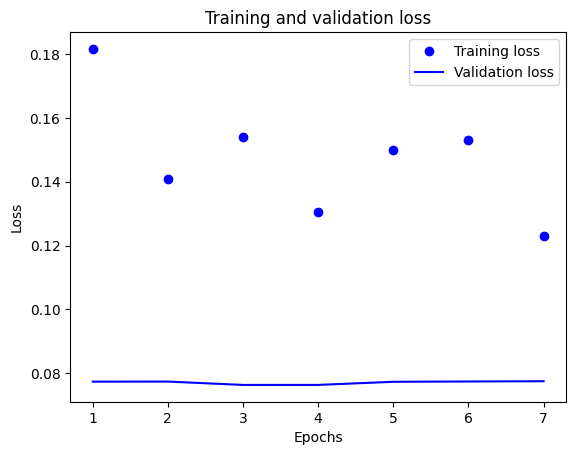

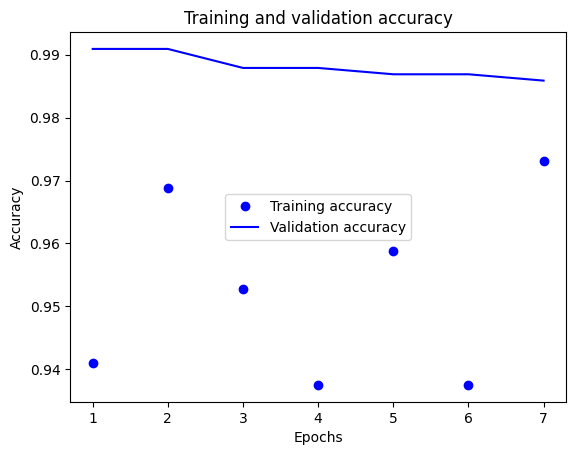

In [59]:
history_ft = model_e.fit(
    train_generator3,
    steps_per_epoch=train_generator3.samples // BATCH_SIZE,
    epochs=EPOCHS_FT,
    validation_data=validation_generator3,
    validation_steps=validation_generator3.samples // BATCH_SIZE,
    callbacks=[early_ft, reduce_ft, ckpt_ft],
    verbose=1
)

plot_history(history_ft)

In [60]:
# Final test evaluation (fine-tuned)
test_loss_ft, test_acc_ft = model_e.evaluate(test_generator3, steps=test_generator3.samples // BATCH_SIZE, verbose=1)
print(f'[Fine-Tuned] Test Accuracy: {test_acc_ft:.4f}')


31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 144ms/step - accuracy: 0.9929 - loss: 0.0690
[Fine-Tuned] Test Accuracy: 0.9929


### Summary

We built a new **transfer learning model using EfficientNetB0** instead of VGG16.
EfficientNet is a pretrained network from Keras Applications that is both parameter-efficient and highly accurate. The model was adapted for binary classification (cats vs. dogs) through the following steps:

1. **Base Model (Frozen Weights):**

   * The pretrained EfficientNetB0 was imported with ImageNet weights.
   * The convolutional layers were frozen initially so they acted as a powerful feature extractor.
   * On top of this base, a new classification head was added:

     * `GlobalAveragePooling2D` → `BatchNormalization` → `Dropout(0.4)` → `Dense(256, activation="swish", L2 regularization)` → `BatchNormalization` → `Dropout(0.4)` → `Dense(1, activation="sigmoid")`.
   * Training this head allowed the model to adapt to the cats vs. dogs dataset without disrupting the pretrained convolutional filters.

2. **Fine-Tuning (Unfreezing):**

   * After stabilizing the head, the **last 30 layers of EfficientNet** were unfrozen and trained with a **very low learning rate**.
   * This fine-tuning step allowed the deeper convolutional layers to adjust more closely to our dataset while preserving the general image features learned from ImageNet.

3. **Optimization Techniques Used:**

   * **Advanced data augmentation** (rotations, shifts, zooms, brightness changes, flips, channel shifts) to simulate more training variability.
   * **Regularization** with dropout (0.4) and L2 weight penalties to reduce overfitting.
   * **Callbacks** such as EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint to stabilize learning and capture the best model weights.


### Results

* **Final Test Accuracy:** `99.29%` with a loss of `0.0690`.
* This is an excellent result in my opinion, showing near-perfect generalization on unseen data.

**Graph Interpretation:**

* **Training and Validation Loss:**
  The training loss fluctuated but remained slightly higher than validation loss throughout fine-tuning. The validation loss stayed **very stable around ~0.078**, showing that the model generalizes consistently without overfitting.

* **Training and Validation Accuracy:**
  Validation accuracy quickly rose above **99%** in the first epoch and remained stable around **98.5–99%**.
  Training accuracy hovered between **93–97%**, slightly below validation, which suggests that augmentation and regularization prevented the model from overfitting too tightly to the training set.
  
  This stability in validation performance while training accuracy oscillated demonstrates that the model has learned strong and generalizable features, and the fine-tuned layers were able to adapt without overfitting.

### Conclusion

Using **EfficientNetB0 transfer learning**, **custom classification layers**, **fine-tuning of selected layers**, and **optimization**, we achieved a model that classifies cats vs. dogs with **~99.3% accuracy** on the test set.

This level of performance highlights both the strength of modern pretrained architectures and the effectiveness of a well-structured fine-tuning pipeline.

# Image prediction with fine-tuned EfficientNet model

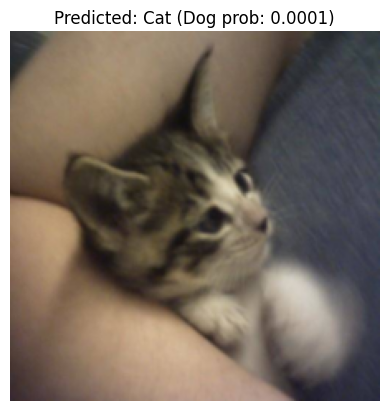

('Cat', 8.938316750572994e-05)

In [64]:
import io, requests
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

# Use the same preprocess function and image size as training
try:
    from tensorflow.keras.applications.efficientnet import preprocess_input
except Exception:
    from keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224  # must match what we trained with

# Label mapping (matches alphabetical order of directories: 'cats', 'dogs')
IDX2LABEL = {0: "Cat", 1: "Dog"}

def _load_image_from_path_or_url(path_or_url, target_size=(IMG_SIZE, IMG_SIZE)):
    """Load an image from local path or URL, resize and return PIL image."""
    if path_or_url.startswith("http://") or path_or_url.startswith("https://"):
        resp = requests.get(path_or_url, timeout=10)
        resp.raise_for_status()
        img = Image.open(io.BytesIO(resp.content))
    else:
        img = Image.open(path_or_url)
    # Ensure 3 channels and correct orientation
    img = ImageOps.exif_transpose(img).convert("RGB")
    img = img.resize(target_size, Image.BILINEAR)
    return img

def predict_image(path_or_url, threshold=0.5, show=True):
    """
    Predict Cat vs Dog on a single image using the trained model_e.
    Returns (pred_label, prob_dog).
    """
    pil_img = _load_image_from_path_or_url(path_or_url)
    x = np.array(pil_img, dtype=np.float32)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    # Use the fine-tuned model (model_e)
    raw = model_e.predict(x, verbose=0)[0][0]  # sigmoid output
    prob_dog = float(raw)
    pred_idx = 1 if prob_dog >= threshold else 0
    pred_label = IDX2LABEL[pred_idx]

    if show:
        plt.imshow(pil_img)
        plt.axis("off")
        plt.title(f"Predicted: {pred_label} (Dog prob: {prob_dog:.4f})")
        plt.show()

    return pred_label, prob_dog

# Prompt Input Here:
predict_image("cat.1090.jpg")
# predict_image("https://images.unsplash.com/photo-1518717758536-85ae29035b6d")
